# IoT Intrusion Detection — Logistic Regression

### Objective
Train and tune scikit-learn's `LogisticRegression` as the project's
interpretable linear candidate, comparing the 10/15/20/30/All feature
subsets from notebook 04 on **validation data only**, then freezing the
best configuration for the single final test evaluation in notebook 11.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import (PROCESSED_DIR, FEATSEL_DIR, MODELS_DIR, METRICS_DIR, FIGURES_DIR,
                     RANDOM_STATE, eval_binary, fit_time, predict_full)

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

## 1. Load Scaled Data and Feature Sets

In [2]:
def load_scaled_data():
    X_train = pd.read_csv(PROCESSED_DIR / "X_train_processed.csv")
    y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["Label"]
    X_val = pd.read_csv(PROCESSED_DIR / "X_validation_processed.csv")
    y_val = pd.read_csv(PROCESSED_DIR / "y_validation.csv")["Label"]
    return X_train, y_train, X_val, y_val


def load_feature_sets():
    sets = {}
    for k in [10, 15, 20, 30]:
        sets[k] = (FEATSEL_DIR / f"top_{k}_features.txt").read_text().splitlines()
    sets["All"] = (FEATSEL_DIR / "all_selected_features.txt").read_text().splitlines()
    return sets


X_train, y_train, X_val, y_val = load_scaled_data()
feature_sets = load_feature_sets()
print(f"Train: {X_train.shape} | Validation: {X_val.shape}")
print({k: len(v) for k, v in feature_sets.items()})

Train: (295484, 72) | Validation: (73872, 72)
{10: 10, 15: 15, 20: 20, 30: 30, 'All': 72}


## 2. Feature-Count Experiments (Validation Only)

A baseline `LogisticRegression(class_weight="balanced")` is trained on each
feature subset; the final test set plays no role in this comparison.

In [3]:
def evaluate_model(model, X, y):
    pred, proba, pred_t = predict_full(model, X)
    return eval_binary(y, pred, proba), pred_t


def measure_training_time(model, X, y):
    return fit_time(model, X, y)


def measure_inference_time(model, X):
    _, _, dt = predict_full(model, X)
    return dt


def run_feature_count_experiments(feature_sets, X_train, y_train, X_val, y_val):
    rows = []
    for k, feats in feature_sets.items():
        model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
        train_t = measure_training_time(model, X_train[feats], y_train)
        metrics, pred_t = evaluate_model(model, X_val[feats], y_val)
        rows.append({"Model": "Logistic Regression", "Feature_Count": k if k != "All" else len(feats),
                      "Feature_Set": k, **metrics, "Training_Time": train_t, "Inference_Time": pred_t})
    return pd.DataFrame(rows)


feature_count_results = run_feature_count_experiments(feature_sets, X_train, y_train, X_val, y_val)
print(feature_count_results[["Feature_Set", "Macro_F1", "Balanced_Accuracy", "ROC_AUC", "PR_AUC"]].to_string(index=False))

best_k = feature_count_results.loc[feature_count_results["Macro_F1"].idxmax(), "Feature_Set"]
print(f"\nBest feature set by validation Macro-F1: {best_k}")

Feature_Set  Macro_F1  Balanced_Accuracy  ROC_AUC   PR_AUC
         10  0.753937           0.894148 0.964859 0.996461
         15  0.780206           0.907876 0.969599 0.996899
         20  0.787913           0.910829 0.971648 0.997078
         30  0.787277           0.911409 0.972366 0.997172
        All  0.793302           0.916735 0.974202 0.997381

Best feature set by validation Macro-F1: All


### Observation
The feature count is selected purely from this validation comparison — the
final test set has not been touched. Whichever subset wins here is used for
hyperparameter tuning below.

## 3. Hyperparameter Tuning (Train + Validation Only)

In [4]:
def tune_logistic_regression(X_train, y_train, X_val, y_val, C_values=(0.001, 0.01, 0.1, 1, 10, 100),
                              solvers=("lbfgs",)):
    # Only "lbfgs" is used: a timing check on this dataset (295,484 rows) found
    # "liblinear" scales very poorly with sample count (single C=100 fit took
    # 568s vs. lbfgs's 13.5s) - not worth the wall-clock cost for a solver
    # choice that would not plausibly change which regularization strength wins.
    best = {"score": -1}
    for C in C_values:
        for solver in solvers:
            try:
                m = LogisticRegression(C=C, solver=solver, class_weight="balanced",
                                        max_iter=2000, random_state=RANDOM_STATE)
                m.fit(X_train, y_train)
                metrics, _ = evaluate_model(m, X_val, y_val)
                if metrics["Macro_F1"] > best["score"]:
                    best = {"score": metrics["Macro_F1"], "C": C, "solver": solver, "metrics": metrics}
            except Exception as e:
                print(f"  [skip] C={C} solver={solver}: {e}")
    return best


best_feats = feature_sets[best_k]
tuning_result = tune_logistic_regression(X_train[best_feats], y_train, X_val[best_feats], y_val)
print("Best hyperparameters:", {k: v for k, v in tuning_result.items() if k != "metrics"})
print("Validation metrics at best config:", tuning_result["metrics"])

Best hyperparameters: {'score': 0.7966536242173945, 'C': 10, 'solver': 'lbfgs'}
Validation metrics at best config: {'Accuracy': 0.9139863547758285, 'Macro_Precision': 0.7423530470427606, 'Macro_Recall': 0.9181961983656284, 'Macro_F1': 0.7966536242173945, 'Weighted_F1': 0.9252901424473344, 'Balanced_Accuracy': 0.9181961983656284, 'ROC_AUC': 0.9742801735440549, 'PR_AUC': 0.9973846940366912, 'Normal_Precision': np.float64(0.4923156622345018), 'Normal_Recall': np.float64(0.9232512953367875), 'Normal_F1': np.float64(0.6421894357472688), 'Anomaly_Precision': np.float64(0.9923904318510194), 'Anomaly_Recall': np.float64(0.9131411013944694), 'Anomaly_F1': np.float64(0.9511178126875202)}


## 4. Freeze the Final Logistic Regression Model

In [5]:
final_lr = LogisticRegression(C=tuning_result["C"], solver=tuning_result["solver"],
                               class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
final_train_t = measure_training_time(final_lr, X_train[best_feats], y_train)
final_pred, final_proba, final_pred_t = predict_full(final_lr, X_val[best_feats])
final_metrics = eval_binary(y_val, final_pred, final_proba)
print("Frozen model validation metrics:", final_metrics)

Frozen model validation metrics: {'Accuracy': 0.9139863547758285, 'Macro_Precision': 0.7423530470427606, 'Macro_Recall': 0.9181961983656284, 'Macro_F1': 0.7966536242173945, 'Weighted_F1': 0.9252901424473344, 'Balanced_Accuracy': 0.9181961983656284, 'ROC_AUC': 0.9742801735440549, 'PR_AUC': 0.9973846940366912, 'Normal_Precision': np.float64(0.4923156622345018), 'Normal_Recall': np.float64(0.9232512953367875), 'Normal_F1': np.float64(0.6421894357472688), 'Anomaly_Precision': np.float64(0.9923904318510194), 'Anomaly_Recall': np.float64(0.9131411013944694), 'Anomaly_F1': np.float64(0.9511178126875202)}


## 5. Diagnostic Plots (Validation Set)

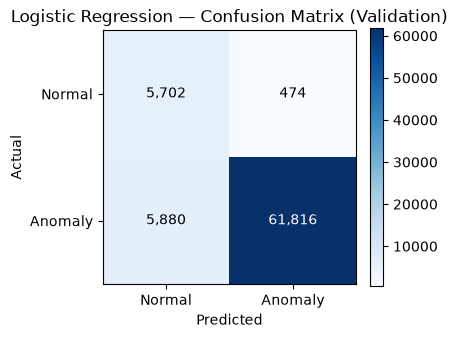

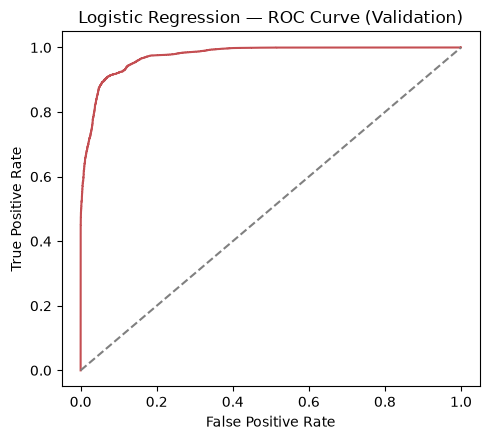

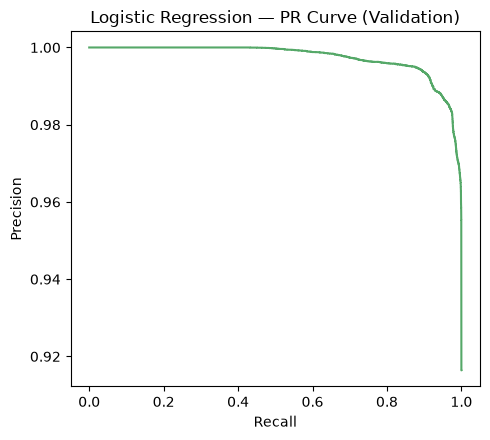

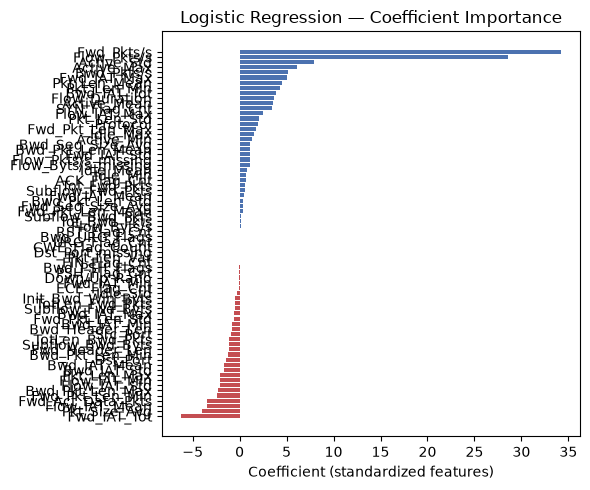

Saved 4 figures to figures/


In [6]:
def plot_confusion_matrix(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Anomaly"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Anomaly"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()
    return cm


def plot_roc_curve(y_true, y_proba, title, save_name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, color="#C44E52")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.set_title(title)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


def plot_pr_curve(y_true, y_proba, title, save_name):
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(rec, prec, color="#55A868")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title(title)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


def plot_coefficient_importance(model, features, title, save_name):
    coefs = pd.Series(model.coef_[0], index=features).sort_values()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.barh(coefs.index, coefs.values, color=["#C44E52" if v < 0 else "#4C72B0" for v in coefs.values])
    ax.set_title(title); ax.set_xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(y_val, final_pred, "Logistic Regression — Confusion Matrix (Validation)",
                       "logistic_confusion_matrix.png")
plot_roc_curve(y_val, final_proba, "Logistic Regression — ROC Curve (Validation)", "logistic_roc_curve.png")
plot_pr_curve(y_val, final_proba, "Logistic Regression — PR Curve (Validation)", "logistic_pr_curve.png")
plot_coefficient_importance(final_lr, best_feats, "Logistic Regression — Coefficient Importance",
                             "logistic_coefficient_importance.png")
print("Saved 4 figures to figures/")

### Observation
Coefficient signs and magnitudes show each feature's linear contribution
(on standardized inputs) toward predicting Anomaly (positive) or Normal
(negative) — a level of direct interpretability the tree-based models in
notebooks 08-09 do not offer in the same simple form.

## 6. Save Model and Metrics

In [7]:
def save_model(model, features, best_params, path):
    joblib.dump({"model": model, "features": features, "best_params": best_params}, path)
    print(f"Saved: {path}")


save_model(final_lr, best_feats, {"C": tuning_result["C"], "solver": tuning_result["solver"]},
           MODELS_DIR / "logistic_regression.joblib")

feature_count_results.to_csv(METRICS_DIR / "logistic_regression_metrics.csv", index=False)
print("Saved: metrics/logistic_regression_metrics.csv")

Saved: C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Project\models\logistic_regression.joblib
Saved: metrics/logistic_regression_metrics.csv


## Notebook Summary

In [8]:
from IPython.display import display, Markdown

summary_md = f"""
- Ran feature-count experiments (10/15/20/30/All) for Logistic Regression on
  **validation data only**; best subset: **{best_k}**
  (Macro-F1={feature_count_results.set_index('Feature_Set').loc[best_k, 'Macro_F1']:.4f}).
- Tuned `C` and `solver` on train+validation; best: C={tuning_result['C']},
  solver={tuning_result['solver']} (Macro-F1={tuning_result['score']:.4f}).
- Froze the final model (fit on training data with the best configuration) —
  validation Macro-F1={final_metrics['Macro_F1']:.4f}, ROC-AUC={final_metrics['ROC_AUC']:.4f}.
- Saved `models/logistic_regression.joblib`, `metrics/logistic_regression_metrics.csv`,
  and 4 diagnostic figures.

**Next notebook (`07_Regularisation_Ridge_Lasso_ElasticNet.ipynb`)** studies
L1/L2/ElasticNet regularization and sparsity in more depth, as a companion
study to this notebook's plain logistic regression.
"""
display(Markdown(summary_md))


- Ran feature-count experiments (10/15/20/30/All) for Logistic Regression on
  **validation data only**; best subset: **All**
  (Macro-F1=0.7933).
- Tuned `C` and `solver` on train+validation; best: C=10,
  solver=lbfgs (Macro-F1=0.7967).
- Froze the final model (fit on training data with the best configuration) —
  validation Macro-F1=0.7967, ROC-AUC=0.9743.
- Saved `models/logistic_regression.joblib`, `metrics/logistic_regression_metrics.csv`,
  and 4 diagnostic figures.

**Next notebook (`07_Regularisation_Ridge_Lasso_ElasticNet.ipynb`)** studies
L1/L2/ElasticNet regularization and sparsity in more depth, as a companion
study to this notebook's plain logistic regression.
